In [1]:
import os

OUTPUT_DIR = "outputs/exploratory_data_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder:", os.path.abspath(OUTPUT_DIR))

Output folder: c:\Users\Hardy\Desktop\UCSD\DSC180\Simulation-coding-exercises-for-teaching-probability-theory\outputs\exploratory_data_analysis


In [2]:
def save_table(df, name):
    path = os.path.join(OUTPUT_DIR, f"{name}.csv")
    df.to_csv(path, index=False)
    print(f"Saved table -> {path}")

In [3]:
import matplotlib.pyplot as plt

import re

def save_current_fig(name):
    # remove illegal filename chars
    name = re.sub(r'[\\/*?:"<>|]', "", name)
    
    path = os.path.join(OUTPUT_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure ->", path)

# Score Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [6]:
df_assess = pd.read_csv("data/cleaned/final_assessment.csv")
df_grades = pd.read_csv("data/cleaned/grades.csv")
df_status = pd.read_csv("data/cleaned/status.csv")

In [7]:
display(df_assess.head())
display(df_grades.head())
display(df_status.head())

,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0
3,6,1.00,2.0,1.0,3.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,2.0,1.0,4.0,0.0,2.0,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,5.0,0.0,0.0,0.6,1.0,0.0,1.0
4,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0


,id,coding_score,handwritten_score,final_score,final_score_adj
0,0,NaN,NaN,0.737705,0.616393
1,1,0.928571,NaN,0.754098,0.639344
2,3,0.857143,1.0,0.836066,0.590164
3,6,NaN,1.0,0.508197,0.262295
4,9,0.904764,NaN,0.672131,0.511475


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [8]:
df_status = df_status[df_status["completed"] == 1].copy()

print("Completed students:", df_status.shape[0])
display(df_status["section"].value_counts())

Completed students: 50


section
1    18
2    12
4    11
3     9
Name: count, dtype: int64

In [9]:
df_id = (
    df_grades
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("ID-level shape:", df_id.shape)
display(df_id.head())

ID-level shape: (50, 6)


,id,coding_score,handwritten_score,final_score,final_score_adj,section
0,0,NaN,NaN,0.737705,0.616393,1
1,1,0.928571,NaN,0.754098,0.639344,2
2,3,0.857143,1.0,0.836066,0.590164,4
3,6,NaN,1.0,0.508197,0.262295,3
4,9,0.904764,NaN,0.672131,0.511475,2


In [10]:
df_item = (
    df_assess
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("Item-level shape:", df_item.shape)
display(df_item.head())

Item-level shape: (50, 38)


,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level,section
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0,1
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0,2
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0,4
3,6,1.00,2.0,1.0,3.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,2.0,1.0,4.0,0.0,2.0,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,5.0,0.0,0.0,0.6,1.0,0.0,1.0,3
4,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0,2


In [11]:
df_id["group"] = df_id["section"]
df_item["group"] = df_item["section"]

### 1. Final assessment scores by group（boxplot）

Saved figure -> outputs/exploratory_data_analysis\Final Assessment Scores by Group.png


C:\Users\Hardy\AppData\Local\Temp\ipykernel_10192\1554892452.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


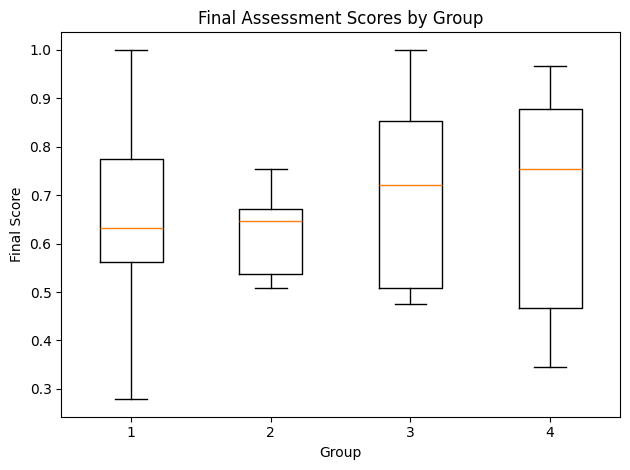

In [12]:
groups = sorted(df_id["group"].unique())
data = [df_id.loc[df_id["group"] == g, "final_score"] for g in groups]

plt.figure()
plt.boxplot(data, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score")
plt.title("Final Assessment Scores by Group")
plt.tight_layout()

save_current_fig("Final Assessment Scores by Group")
plt.show()

### 2. Final assessment scores adjusted for confidence（boxplot）

C:\Users\Hardy\AppData\Local\Temp\ipykernel_10192\3389975434.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_adj, labels=groups, showfliers=False)


Saved figure -> outputs/exploratory_data_analysis\Final Assessment Scores (Adjusted) by Group.png


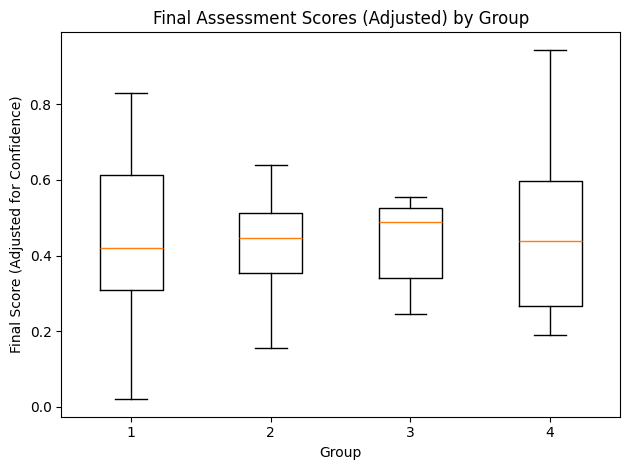

In [13]:
data_adj = [df_id.loc[df_id["group"] == g, "final_score_adj"] for g in groups]

plt.figure()
plt.boxplot(data_adj, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score (Adjusted for Confidence)")
plt.title("Final Assessment Scores (Adjusted) by Group")
plt.tight_layout()

save_current_fig("Final Assessment Scores (Adjusted) by Group")
plt.show()

In [14]:
def boxplot_stats_series(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return pd.Series({
            "n": 0, "mean": np.nan, "std": np.nan,
            "min": np.nan, "q1": np.nan, "median": np.nan, "q3": np.nan, "max": np.nan,
            "iqr": np.nan, "whisker_low": np.nan, "whisker_high": np.nan
        })

    q1 = s.quantile(0.25)
    med = s.quantile(0.50)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr

    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(ddof=1),
        "min": s.min(),
        "q1": q1,
        "median": med,
        "q3": q3,
        "max": s.max(),
        "iqr": iqr,
        "whisker_low": s[s >= low_fence].min(),
        "whisker_high": s[s <= high_fence].max()
    })

s = df_id.groupby("group")["final_score_adj"].apply(boxplot_stats_series)

stats_wide_adj = s.unstack(level=0)

stats_wide_adj.columns = [f"section_{c}" for c in stats_wide_adj.columns]

display(stats_wide_adj)

,section_1,section_2,section_3,section_4
n,18.000000,12.000000,9.000000,11.000000
mean,0.434426,0.422131,0.461566,0.469151
std,0.245942,0.139413,0.176272,0.233982
min,0.019672,0.154098,0.245902,0.190164
q1,0.308197,0.354098,0.340984,0.267213
median,0.419672,0.445902,0.488525,0.439344
q3,0.613115,0.513115,0.524590,0.596721
max,0.829508,0.639344,0.822951,0.944262
iqr,0.304918,0.159016,0.183607,0.329508
whisker_low,0.019672,0.154098,0.245902,0.190164


In [15]:
s_raw = df_id.groupby("group")["final_score"].apply(boxplot_stats_series)
stats_wide_raw = s_raw.unstack(level=0)
stats_wide_raw.columns = [f"section_{c}" for c in stats_wide_raw.columns]

display(stats_wide_raw)

,section_1,section_2,section_3,section_4
n,18.000000,12.000000,9.000000,11.000000
mean,0.629326,0.631148,0.699454,0.684054
std,0.217857,0.160242,0.187810,0.237800
min,0.098361,0.327869,0.475410,0.344262
q1,0.561475,0.536885,0.508197,0.467213
median,0.631148,0.647541,0.721311,0.754098
q3,0.774590,0.672131,0.852459,0.877049
max,1.000000,1.000000,1.000000,0.967213
iqr,0.213115,0.135246,0.344262,0.409836
whisker_low,0.278689,0.508197,0.475410,0.344262


### 3. Standard Deviations/Means by subquestion（rescaled 0–1）

In [16]:
score_cols = [c for c in df_item.columns if c.endswith("_score")]

print("Number of subquestions:", len(score_cols))
print(score_cols)

Number of subquestions: 18
['1.1_score', '1.2_score', '1.3_score', '1.4_score', '2.1_score', '2.2_score', '2.3_score', '2.4_score', '3.1_score', '3.2_score', '3.3_score', '3.4_score', '3.5_score', '4.1_score', '5.1_score', '5.2_score', '5.3_score', '5.4_score']


In [17]:
long_scores = (
    df_item[["id"] + score_cols]
    .melt(
        id_vars="id",
        value_vars=score_cols,
        var_name="subquestion",
        value_name="score"
    )
)

# clean subquestion name: '1.1_score' -> '1.1'
long_scores["subquestion"] = long_scores["subquestion"].str.replace("_score", "", regex=False)

print("Long score table shape:", long_scores.shape)
display(long_scores.head())

Long score table shape: (900, 3)


,id,subquestion,score
0,0,1.1,0.75
1,1,1.1,0.75
2,3,1.1,1.00
3,6,1.1,1.00
4,9,1.1,0.50


In [18]:
std_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(std_score=("score", "std"))
    .reset_index()
    .sort_values("std_score", ascending=False)
)

In [19]:
mean_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(mean_score=("score", "mean"))
    .reset_index()
    .sort_values("mean_score")
)

In [20]:
subquestion_summary = (
    long_scores
    .groupby("subquestion")
    .agg(
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        n=("score", "count")
    )
    .reset_index()
    .sort_values("subquestion")
)

display(subquestion_summary)

,subquestion,mean_score,std_score,n
0,1.1,0.825,0.197239,50
1,1.2,0.872,0.257967,50
2,1.3,0.700,0.462910,50
3,1.4,0.770,0.352976,50
4,2.1,0.680,0.471212,50
5,2.2,0.860,0.350510,50
6,2.3,0.980,0.141421,50
7,2.4,0.640,0.484873,50
8,3.1,0.800,0.404061,50
9,3.2,0.700,0.462910,50


### 4. Boxplots by section for any subquestions of interest

In [21]:
# helper function to add rank labels
def add_rank_label(df, label_prefix, score_col, ascending):
    df = df.sort_values(score_col, ascending=ascending).head(2).copy()
    df["selection_reason"] = [
        f"1st {label_prefix}",
        f"2nd {label_prefix}"
    ]
    return df


# 1) highest mean
highest_mean_2 = add_rank_label(
    subquestion_summary,
    label_prefix="highest mean",
    score_col="mean_score",
    ascending=False
)

# 2) lowest mean
lowest_mean_2 = add_rank_label(
    subquestion_summary,
    label_prefix="lowest mean",
    score_col="mean_score",
    ascending=True
)

# 3) highest std
highest_std_2 = add_rank_label(
    subquestion_summary,
    label_prefix="highest std",
    score_col="std_score",
    ascending=False
)

# 4) lowest std
lowest_std_2 = add_rank_label(
    subquestion_summary,
    label_prefix="lowest std",
    score_col="std_score",
    ascending=True
)

# combine all
interest_subqs = pd.concat([
    highest_mean_2,
    lowest_mean_2,
    highest_std_2,
    lowest_std_2
])

# merge labels if a subquestion appears multiple times
interest_subqs = (
    interest_subqs
    .groupby(["subquestion", "mean_score", "std_score", "n"], as_index=False)
    .agg({
        "selection_reason": lambda x: "; ".join(sorted(set(x)))
    })
    .sort_values("subquestion")
)

display(interest_subqs)

,subquestion,mean_score,std_score,n,selection_reason
0,1.1,0.825,0.197239,50,2nd lowest std
1,1.2,0.872,0.257967,50,2nd highest mean
2,2.3,0.980,0.141421,50,1st highest mean; 1st lowest std
3,3.4,0.560,0.501427,50,1st highest std
4,3.5,0.400,0.494872,50,2nd highest std
5,5.2,0.340,0.478518,50,2nd lowest mean
6,5.4,0.300,0.462910,50,1st lowest mean


In [22]:
# Sanity check: 3.4 and 4.1 are different subquestions by design.
# We test whether their raw score vectors differ in the dataset; if this returns True,
# the two items happen to have identical observed scores in the current sample.
s34 = long_scores[long_scores["subquestion"] == "3.4"]["score"].reset_index(drop=True)
s41 = long_scores[long_scores["subquestion"] == "4.1"]["score"].reset_index(drop=True)

(s34 == s41).all()

np.False_

In [23]:
# merge section info
long_scores_sec = long_scores.merge(
    df_item[["id", "section"]].drop_duplicates(),
    on="id",
    how="left"
)

Saved figure -> outputs/exploratory_data_analysis\barplot_subq_1.1.png


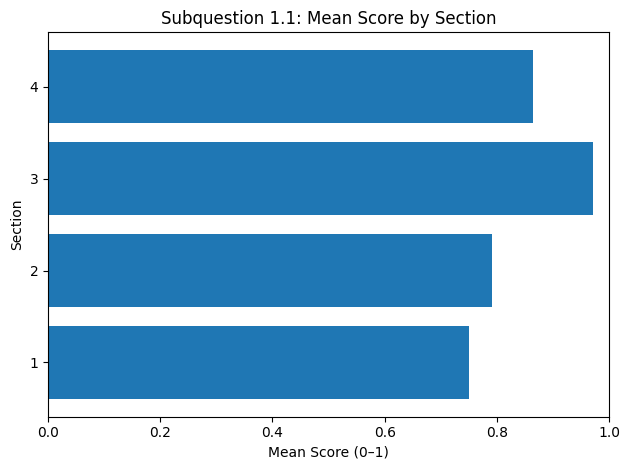

Saved figure -> outputs/exploratory_data_analysis\barplot_subq_1.2.png


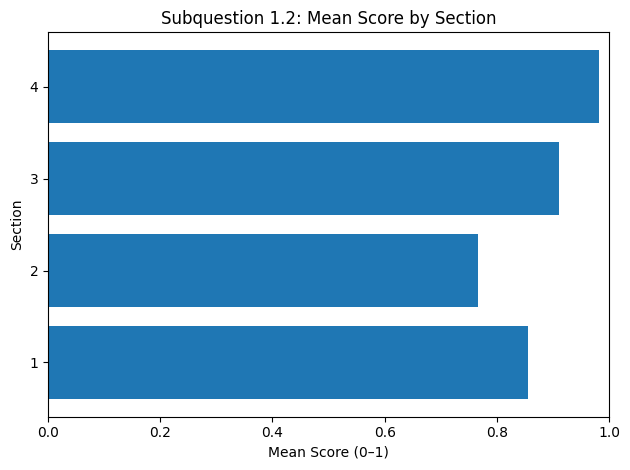

Saved figure -> outputs/exploratory_data_analysis\barplot_subq_2.3.png


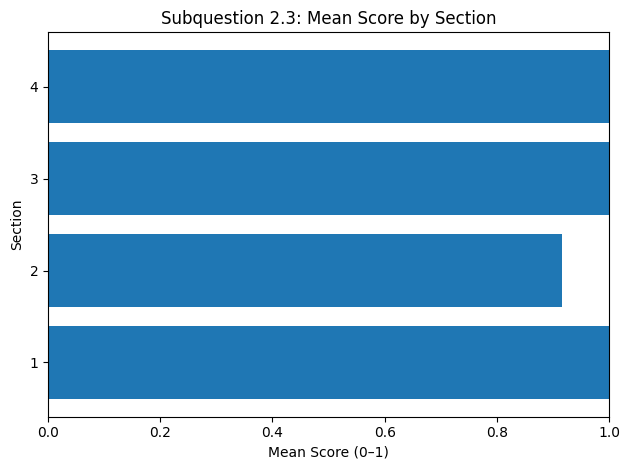

Saved figure -> outputs/exploratory_data_analysis\barplot_subq_3.4.png


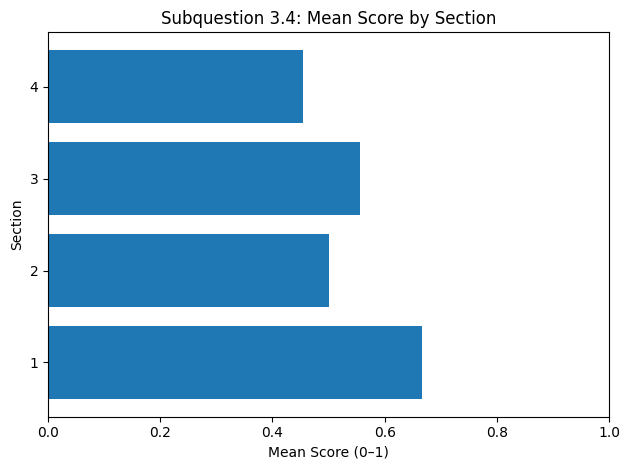

Saved figure -> outputs/exploratory_data_analysis\barplot_subq_3.5.png


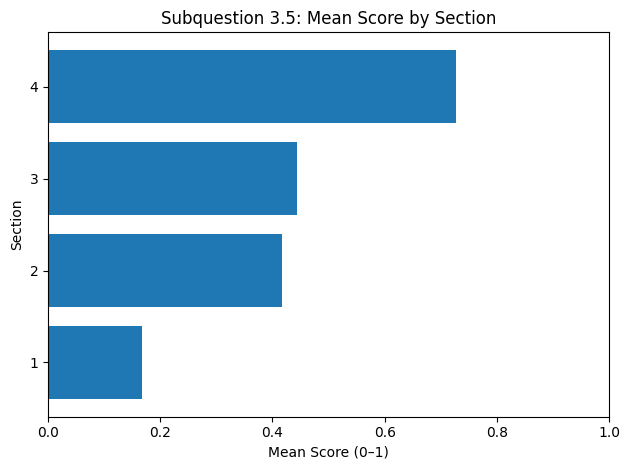

Saved figure -> outputs/exploratory_data_analysis\barplot_subq_5.2.png


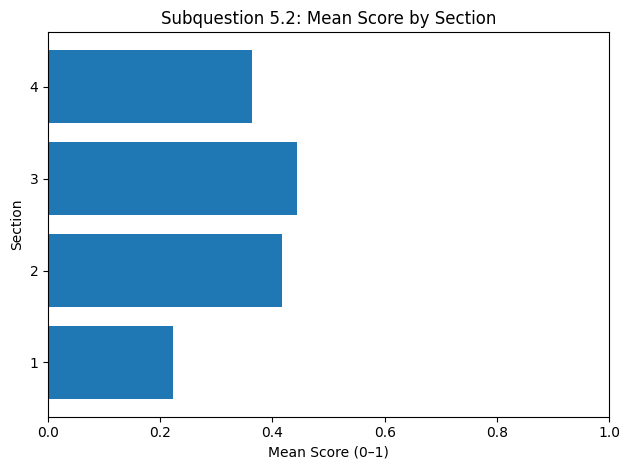

Saved figure -> outputs/exploratory_data_analysis\barplot_subq_5.4.png


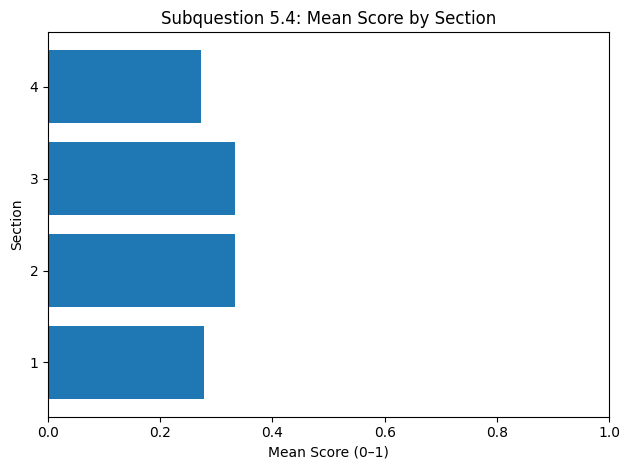

In [24]:
import numpy as np
import matplotlib.pyplot as plt

sections = [1, 2, 3, 4]

for sq in interest_subqs["subquestion"]:
    means = (
        long_scores_sec.loc[long_scores_sec["subquestion"] == sq]
        .groupby("section")["score"]
        .mean()
        .reindex(sections)
    )

    y = np.arange(len(sections))

    plt.figure()
    plt.barh(y, means.values)

    plt.yticks(y, sections)
    plt.xlabel("Mean Score (0–1)")
    plt.ylabel("Section")
    plt.title(f"Subquestion {sq}: Mean Score by Section")
    plt.xlim(0, 1)
    plt.tight_layout()

    save_current_fig(f"barplot_subq_{sq}")

    plt.show()
    plt.close()

### Completeness by group

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df_status = pd.read_csv("data/cleaned/status.csv")

print(df_status.shape)
display(df_status.head())

(95, 3)


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [26]:
df_status["completed"] = (
    df_status["completed"]
    .astype(str)
    .str.upper()
    .map({"TRUE": True, "FALSE": False})
)

print("Completed value counts:")
display(df_status["completed"].value_counts(dropna=False))

Completed value counts:


completed
True     50
False    45
Name: count, dtype: int64

In [27]:
completeness_by_section = (
    df_status
    .groupby("section")
    .agg(
        n_total=("completed", "size"),
        n_completed=("completed", "sum"),      # True = 1
        completion_rate=("completed", "mean")  # proportion TRUE
    )
    .reset_index()
)

display(completeness_by_section)

,section,n_total,n_completed,completion_rate
0,1,24,18,0.750000
1,2,24,12,0.500000
2,3,24,9,0.375000
3,4,23,11,0.478261


Saved figure -> outputs/exploratory_data_analysis\Task Completion Rate by Section.png


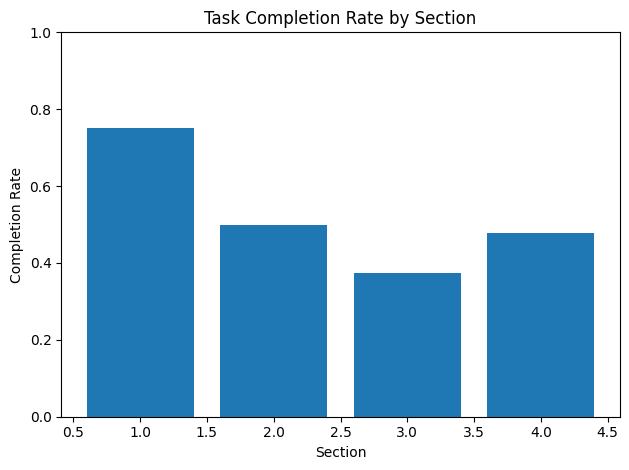

In [28]:
plt.figure()
plt.bar(
    completeness_by_section["section"],
    completeness_by_section["completion_rate"]
)
plt.xlabel("Section")
plt.ylabel("Completion Rate")
plt.ylim(0, 1)
plt.title("Task Completion Rate by Section")
plt.tight_layout()

save_current_fig("Task Completion Rate by Section")
plt.show()

# Confidence Level Analysis

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_assess = pd.read_csv("data/cleaned/final_assessment.csv")
df_status = pd.read_csv("data/cleaned/status.csv")

# keep only completed students
df_status = df_status[df_status["completed"] == 1].copy()

# merge assessment + section
df_item = df_assess.merge(df_status[["id", "section"]], on="id", how="inner")
print("df_item shape:", df_item.shape)

df_item shape: (50, 38)


In [30]:
# identify columns
score_cols = [c for c in df_item.columns if c.endswith("_score")]
conf_cols  = [c for c in df_item.columns if c.endswith("_confident_level")]

print("Num score cols:", len(score_cols))
print("Num conf cols:", len(conf_cols))

# reshape scores long
long_scores = (
    df_item[["id", "section"] + score_cols]
    .melt(id_vars=["id", "section"], value_vars=score_cols,
          var_name="subquestion", value_name="score")
)
long_scores["subquestion"] = long_scores["subquestion"].str.replace("_score", "", regex=False)

# reshape confidence long
long_conf = (
    df_item[["id", "section"] + conf_cols]
    .melt(id_vars=["id", "section"], value_vars=conf_cols,
          var_name="subquestion", value_name="confidence")
)
long_conf["subquestion"] = long_conf["subquestion"].str.replace("_confident_level", "", regex=False)

# merge into one tidy table: one row per (id, section, subquestion)
long_sc = long_scores.merge(long_conf, on=["id", "section", "subquestion"], how="inner")

# type cleaning
long_sc["score"] = pd.to_numeric(long_sc["score"], errors="coerce")
long_sc["confidence"] = pd.to_numeric(long_sc["confidence"], errors="coerce")

print("long_sc shape:", long_sc.shape)
display(long_sc.head())

Num score cols: 18
Num conf cols: 18
long_sc shape: (900, 5)


,id,section,subquestion,score,confidence
0,0,1,1.1,0.75,4.0
1,1,2,1.1,0.75,5.0
2,3,4,1.1,1.00,4.0
3,6,3,1.1,1.00,2.0
4,9,2,1.1,0.50,4.0


In [31]:
conf_fill_by_section = (
    long_sc
    .groupby("section", dropna=False)
    .agg(
        n_rows=("confidence", "size"),
        conf_non_missing=("confidence", lambda s: s.notna().sum()),
        conf_fill_rate=("confidence", lambda s: s.notna().mean())
    )
    .reset_index()
)

display(conf_fill_by_section)

,section,n_rows,conf_non_missing,conf_fill_rate
0,1,324,313,0.966049
1,2,216,213,0.986111
2,3,162,162,1.000000
3,4,198,188,0.949495


Saved figure -> outputs/exploratory_data_analysis\Mean Confidence Level by Section (Completed only).png


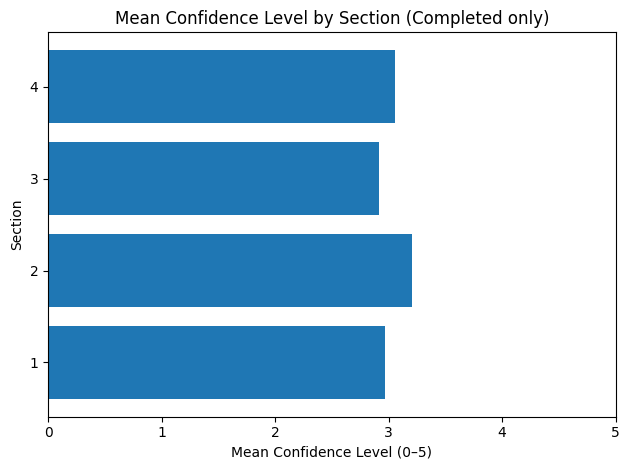

In [32]:
# keep non-missing confidence only
conf_nonmiss = long_sc.dropna(subset=["confidence"]).copy()

# ensure section is clean and fixed to 1-4
conf_nonmiss["section"] = conf_nonmiss["section"].astype(int)
sections = [1, 2, 3, 4]

# mean confidence by section
mean_conf = (
    conf_nonmiss
    .groupby("section")["confidence"]
    .mean()
    .reindex(sections)
)

# plot (horizontal barplot)
y = np.arange(len(sections))

plt.figure()
plt.barh(y, mean_conf.values)

plt.yticks(y, sections)  # force only 1,2,3,4
plt.xlabel("Mean Confidence Level (0–5)")
plt.ylabel("Section")
plt.title("Mean Confidence Level by Section (Completed only)")
plt.xlim(0, 5)

plt.tight_layout()
save_current_fig("Mean Confidence Level by Section (Completed only)")
plt.show()
plt.close()

,confidence,n,mean_score,std_score
0,0.0,109,0.251835,0.419210
1,1.0,69,0.384783,0.461639
2,2.0,101,0.622277,0.455767
3,3.0,189,0.710053,0.429007
4,4.0,221,0.830317,0.353822
5,5.0,187,0.911230,0.274120


Saved figure -> outputs/exploratory_data_analysis\Overall Calibration Mean Score by Confidence.png


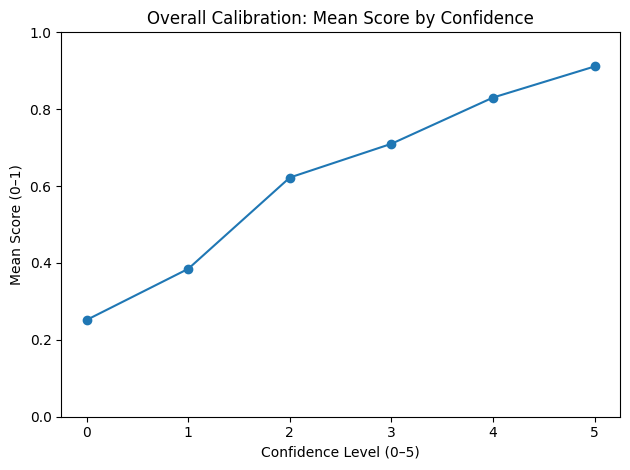

In [33]:
calib_overall = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby("confidence", dropna=False)
    .agg(
        n=("score", "size"),
        mean_score=("score", "mean"),
        std_score=("score", "std")
    )
    .reset_index()
    .sort_values("confidence")
)

display(calib_overall)

plt.figure()
plt.plot(calib_overall["confidence"], calib_overall["mean_score"], marker="o")
plt.xlabel("Confidence Level (0–5)")
plt.ylabel("Mean Score (0–1)")
plt.title("Overall Calibration: Mean Score by Confidence")
plt.ylim(0, 1)
plt.tight_layout()

save_current_fig("Overall Calibration: Mean Score by Confidence")
plt.show()

,section,confidence,n,mean_score
0,1,0.0,52,0.285577
1,1,1.0,28,0.332143
2,1,2.0,28,0.548214
3,1,3.0,57,0.722807
4,1,4.0,67,0.814925
5,1,5.0,81,0.957407
6,2,0.0,16,0.312500
7,2,1.0,17,0.344118
8,2,2.0,29,0.725862
9,2,3.0,45,0.630000


Saved figure -> outputs/exploratory_data_analysis\Calibration by Section Mean Score vs Confidence.png


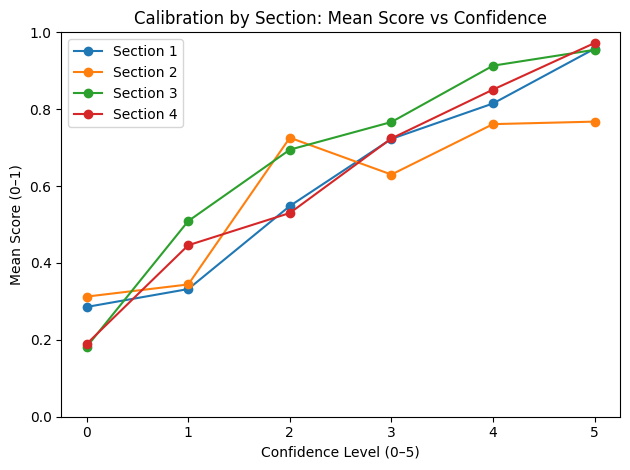

In [34]:
calib_by_section = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby(["section", "confidence"], dropna=False)
    .agg(n=("score", "size"), mean_score=("score", "mean"))
    .reset_index()
    .sort_values(["section", "confidence"])
)

display(calib_by_section.head(20))

plt.figure()
for sec in sorted(calib_by_section["section"].unique()):
    tmp = calib_by_section[calib_by_section["section"] == sec]
    plt.plot(tmp["confidence"], tmp["mean_score"], marker="o", label=f"Section {sec}")
plt.xlabel("Confidence Level (0–5)")
plt.ylabel("Mean Score (0–1)")
plt.title("Calibration by Section: Mean Score vs Confidence")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

save_current_fig("Calibration by Section: Mean Score vs Confidence")
plt.show()

In [35]:
calib_by_subq = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby(["subquestion", "confidence"], dropna=False)
    .agg(
        n=("score", "size"),
        mean_score=("score", "mean"),
        std_score=("score", "std")
    )
    .reset_index()
    .sort_values(["subquestion", "confidence"])
)

display(calib_by_subq.head(30))

# (Optional) pivot to make it easy to compare across confidence levels
calib_pivot = calib_by_subq.pivot(index="subquestion", columns="confidence", values="mean_score")
display(calib_pivot)

,subquestion,confidence,n,mean_score,std_score
0,1.1,1.0,2,1.000000,0.000000
1,1.1,2.0,7,0.678571,0.278174
2,1.1,3.0,8,0.812500,0.221601
3,1.1,4.0,25,0.840000,0.175000
4,1.1,5.0,8,0.875000,0.133631
5,1.2,1.0,1,0.800000,NaN
6,1.2,2.0,7,0.600000,0.461880
7,1.2,3.0,20,0.880000,0.237531
8,1.2,4.0,13,0.969231,0.075107
9,1.2,5.0,9,0.933333,0.141421


confidence,0.0,1.0,2.0,3.0,4.0,5.0
subquestion,,,,,,
1.1,NaN,1.000000,0.678571,0.812500,0.840000,0.875000
1.2,NaN,0.800000,0.600000,0.880000,0.969231,0.933333
1.3,1.000000,0.750000,0.600000,0.631579,0.818182,1.000000
1.4,0.450000,0.550000,0.850000,0.700000,0.958333,1.000000
2.1,0.250000,NaN,0.000000,0.800000,0.777778,0.736842
2.2,1.000000,NaN,0.666667,0.615385,1.000000,1.000000
2.3,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000
2.4,0.166667,0.500000,0.000000,0.666667,0.666667,1.000000
3.1,NaN,0.000000,0.500000,0.666667,0.846154,0.884615


In [36]:
# overall correlation
tmp = long_sc.dropna(subset=["confidence", "score"])
overall_corr = tmp["confidence"].corr(tmp["score"])
print("Overall Pearson corr(confidence, score):", overall_corr)

# correlation by section
corr_by_section = (
    tmp.groupby("section")
       .apply(lambda g: g["confidence"].corr(g["score"]))
       .reset_index(name="corr_conf_score")
)
display(corr_by_section)

Overall Pearson corr(confidence, score): 0.4840764087847881


,section,corr_conf_score
0,1,0.563032
1,2,0.287033
2,3,0.554892
3,4,0.523352
